In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "CrabAgePrediction.csv" #can be easily changed from 'puter to 'puter
data = pd.read_csv(path, delimiter = ",")
data["Sex"] = data["Sex"].map({"M": 1, "F": 2, "I": 3})

display(data)
data.shape

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,2,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,3,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,2,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,3,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6
...,...,...,...,...,...,...,...,...,...
3888,2,1.4625,1.1375,0.3250,24.819987,11.651644,5.854172,6.378637,8
3889,2,1.5500,1.2125,0.4375,34.458817,15.450477,7.172423,9.780577,10
3890,3,0.6250,0.4625,0.1625,2.012815,0.765436,0.524466,0.637864,5
3891,3,1.0625,0.7750,0.2625,10.347568,4.507570,2.338834,2.976698,6


(3893, 9)

R squared: 0.12464066460379497


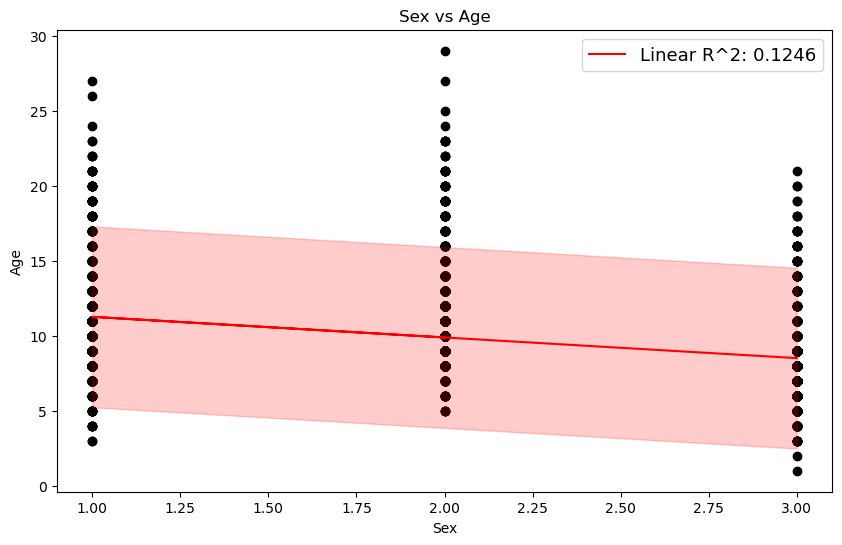

R squared: 0.307995345923039


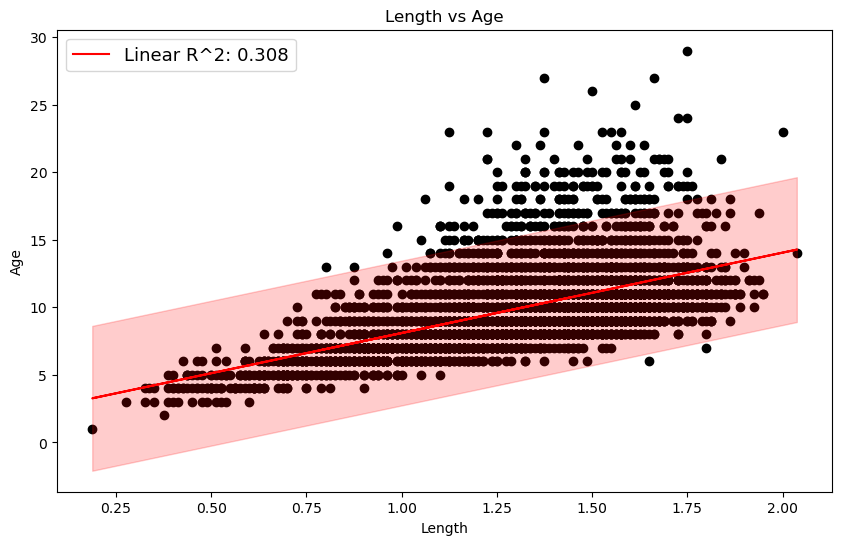

R squared: 0.32929729951164366


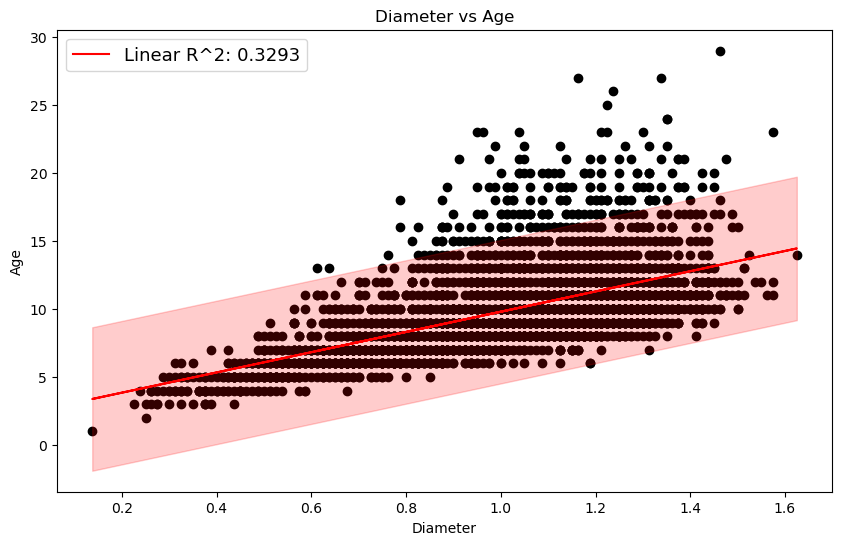

R squared: 0.3046558225235382


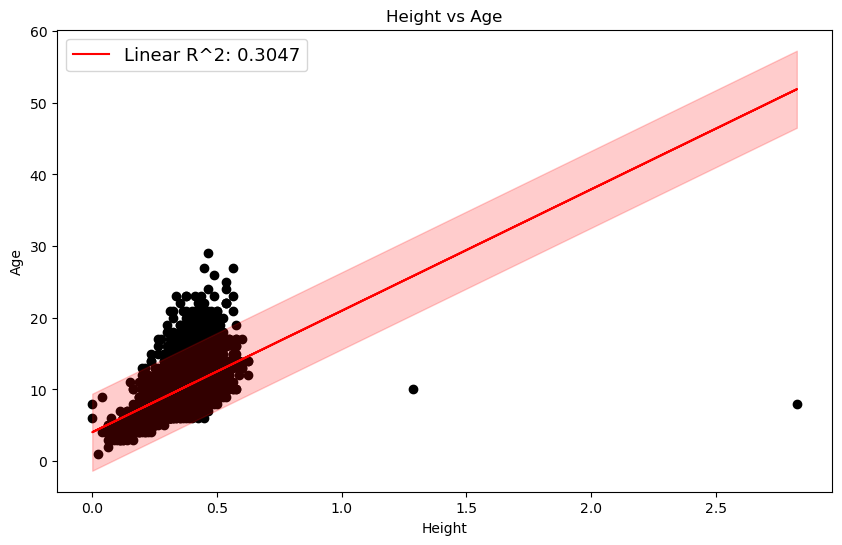

R squared: 0.2903263840043738


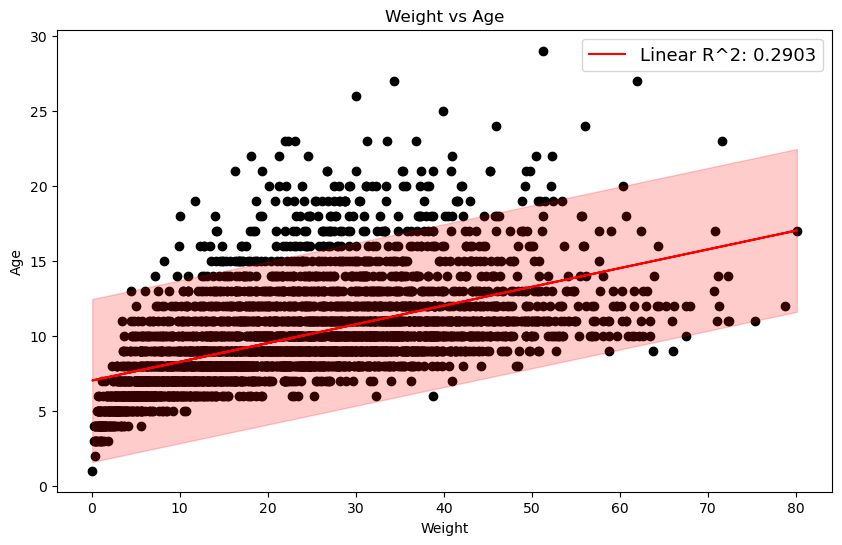

R squared: 0.175359747149602


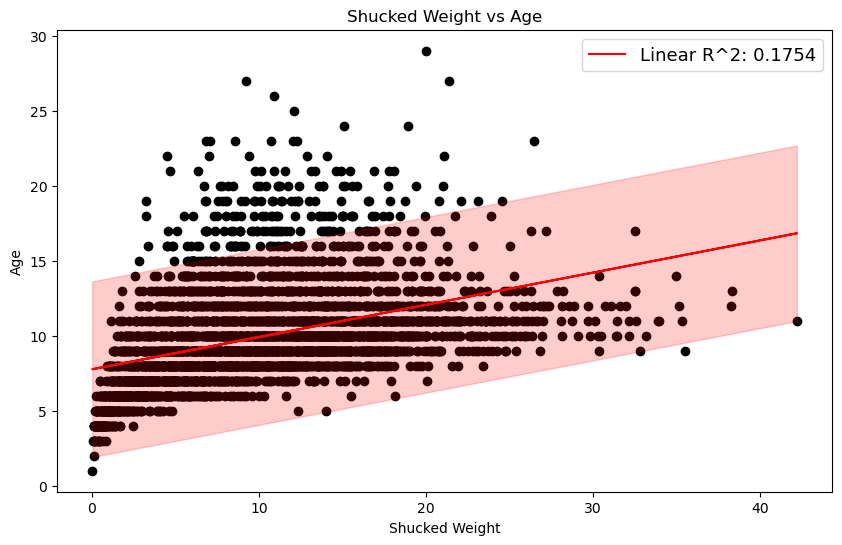

R squared: 0.25132953678746817


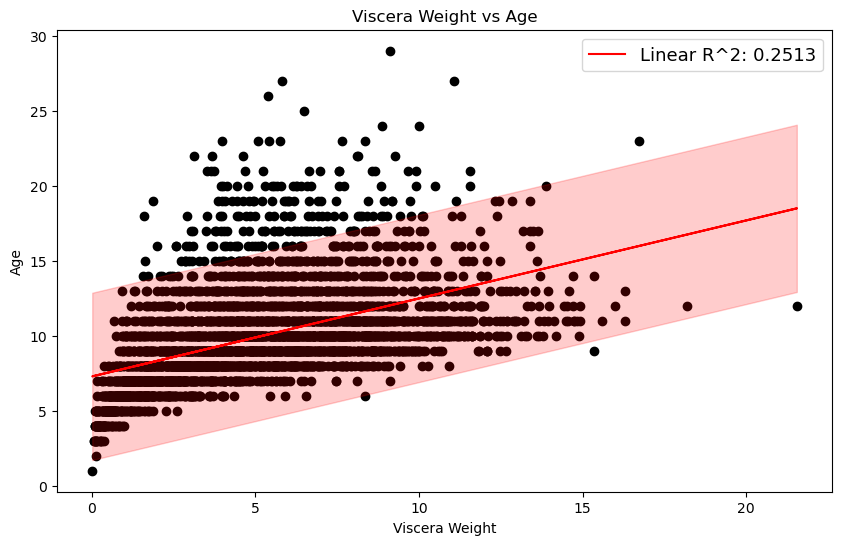

R squared: 0.39086878014369986


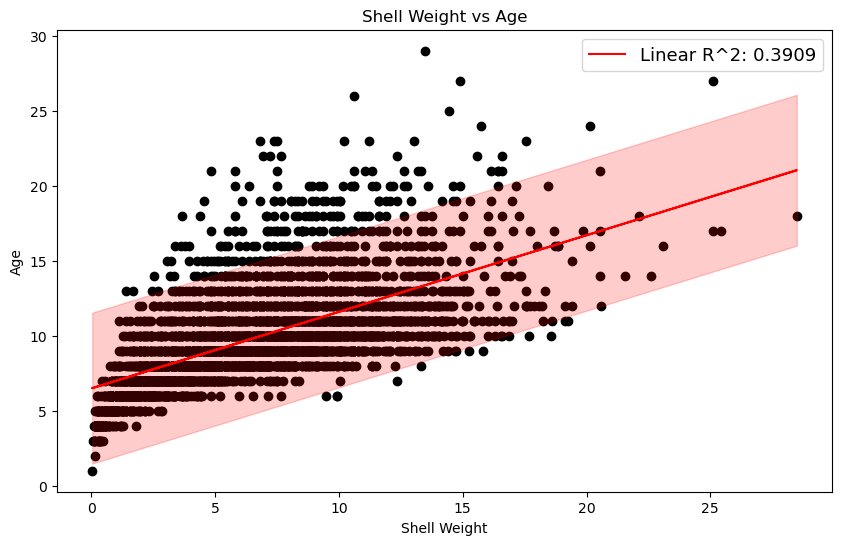

In [182]:
labelList = ["Sex", "Length", "Diameter", "Height", "Weight", "Shucked Weight", "Viscera Weight", "Shell Weight"]
N = 3893

for i in range(8):
    X = data.iloc[:, i]
    Y = data.iloc[:, -1]
    
    mean_X = sum(X) / N
    mean_Y = sum(Y) / N
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    sigma_Y = np.sqrt(sum((Y - mean_Y)**2) / (N - 1))
    sigma_XY = sum((X - mean_X) * (Y - mean_Y)) / (N - 1)
    
    thetahat_1 = sigma_XY / sigma_X**2
    thetahat_0 = mean_Y - (mean_X * thetahat_1)
    yhat = thetahat_0 + (X * thetahat_1)
    
    r_squared = 1 - (sum((Y - yhat)**2) / sum((Y - mean_Y)**2))
    print(f"R squared: {r_squared}")

    sigma2hat = sum((Y - yhat)**2) / (N - 2)
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    var_1 = sigma2hat / ((N - 1) * (sigma_X**2))
    var_0 = (sigma2hat / N) + ((sigma2hat * mean_X**2) / ((N - 1) * (sigma_X**2)))
    std_error = np.sqrt(sigma2hat)

    indSorted = np.argsort(X)
    XSorted = X[indSorted]
    yhatSorted = yhat[indSorted]
    
    plt.figure(figsize = (10, 6))
    plt.scatter(X, Y, color = "k")
    plt.plot(X, yhat, color = "r", label = "Linear R^2: " + str(round(r_squared, 4)))
    plt.fill_between(XSorted, yhatSorted - 2 * std_error, yhatSorted + 2 * std_error, color = "r", alpha = 0.2)
    
    plt.title(labelList[i]+ " vs Age")
    plt.xlabel(labelList[i])
    plt.ylabel("Age")
    plt.legend(fontsize = 13)
    plt.show()

#len: 0.5, diam: 0.5, weight: 0.5, shucked weight: 0.5, 

R squared: 0.3115076379064008


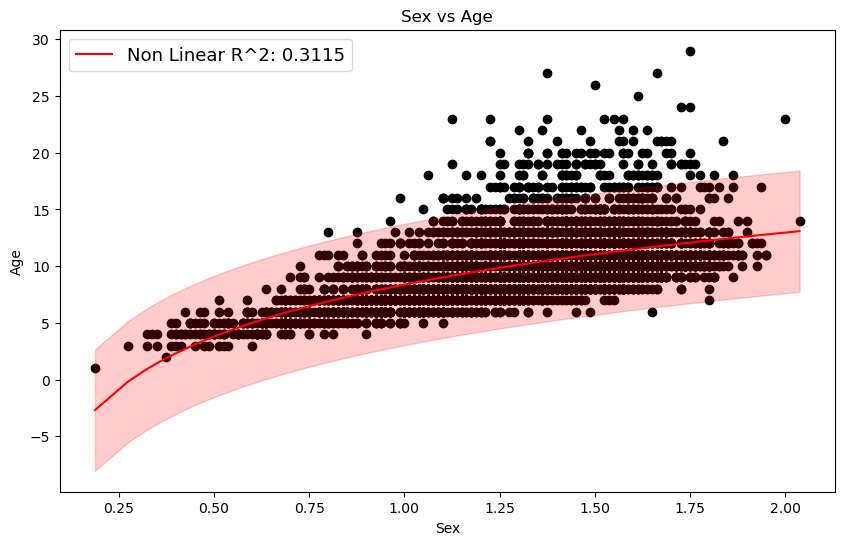

R squared: 0.32972274781661437


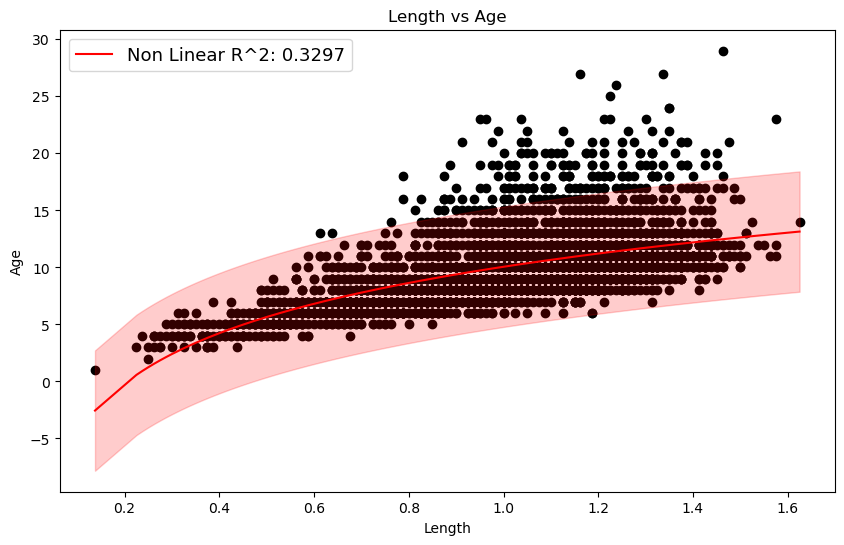

R squared: 0.3393216531293278


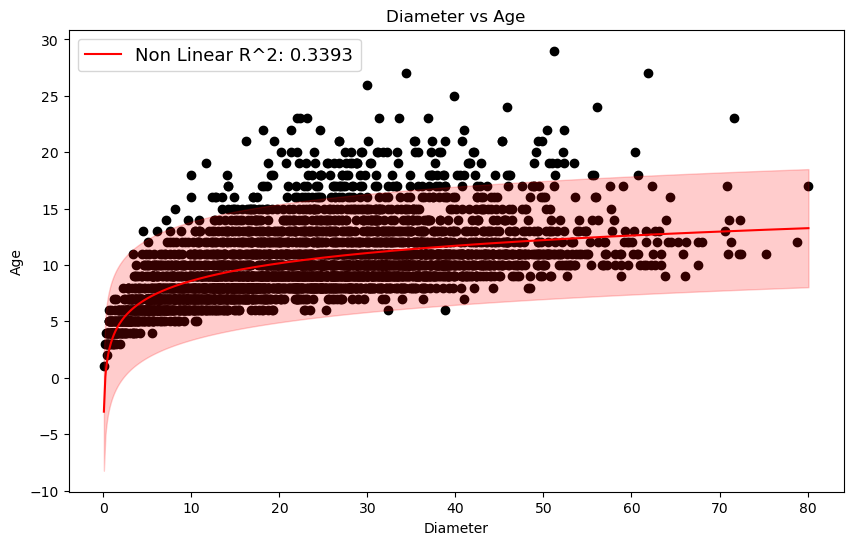

R squared: 0.25896260944304794


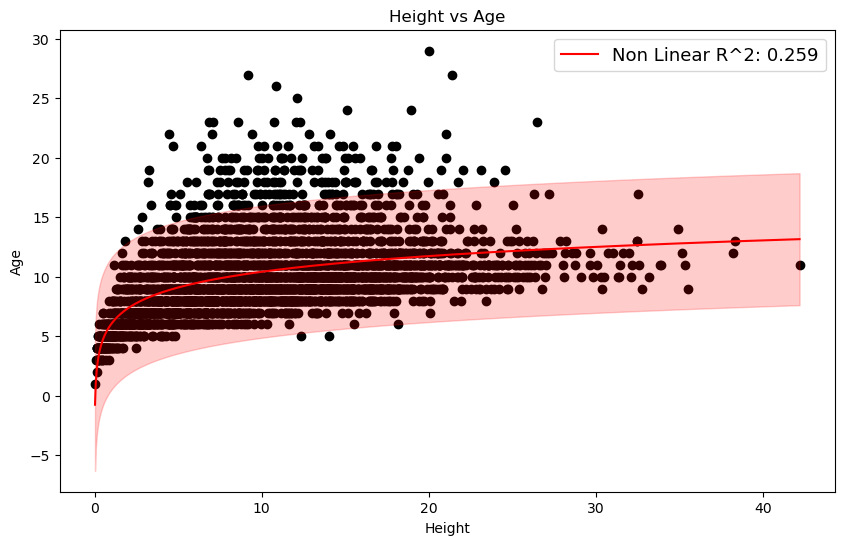

R squared: 0.3183748356207813


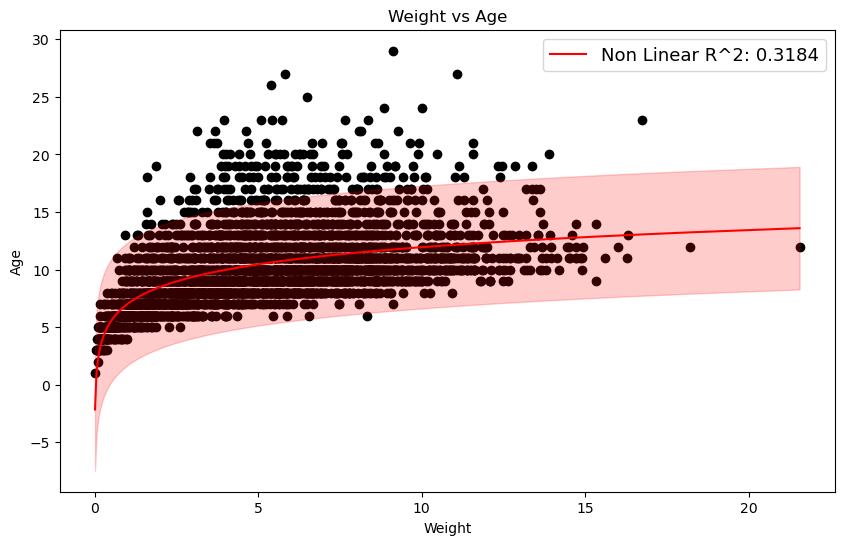

R squared: 0.3993169214358342


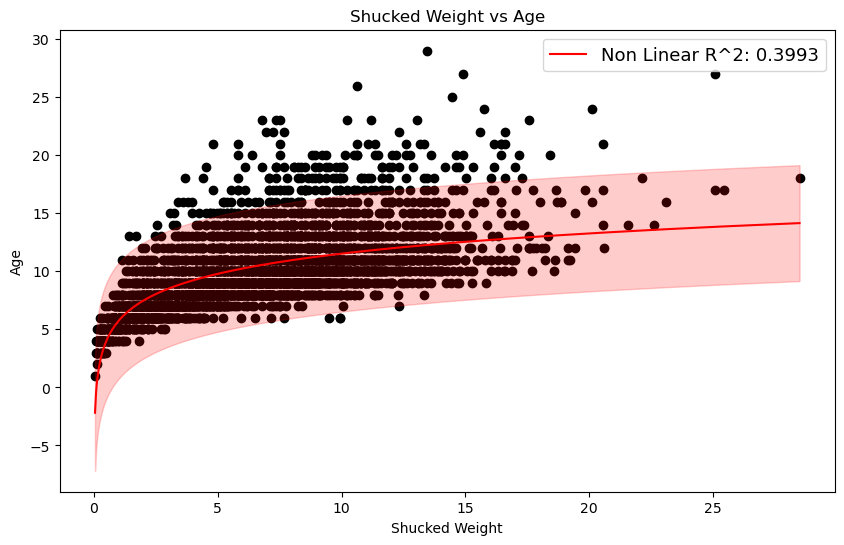

In [190]:
dataList = [data["Length"], data["Diameter"], data["Weight"], data["Shucked Weight"], data["Viscera Weight"], data["Shell Weight"]]
for i in range(6):
    X = np.log(0.5 * dataList[i])
    Y = data["Age"]

    mean_X = sum(X) / N
    mean_Y = sum(Y) / N
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    sigma_Y = np.sqrt(sum((Y - mean_Y)**2) / (N - 1))
    sigma_XY = sum((X - mean_X) * (Y - mean_Y)) / (N - 1)
    
    thetahat_1 = sigma_XY / sigma_X**2
    thetahat_0 = mean_Y - (mean_X * thetahat_1)
    yhat = thetahat_0 + (X * thetahat_1)
    
    r_squared = 1 - (sum((Y - yhat)**2) / sum((Y - mean_Y)**2))
    print(f"R squared: {r_squared}")

    sigma2hat = sum((Y - yhat)**2) / (N - 2)
    sigma_X = np.sqrt(sum((X - mean_X)**2) / (N - 1))
    var_1 = sigma2hat / ((N - 1) * (sigma_X**2))
    var_0 = (sigma2hat / N) + ((sigma2hat * mean_X**2) / ((N - 1) * (sigma_X**2)))
    std_error = np.sqrt(sigma2hat)

    indSorted = np.argsort(dataList[i])
    XSorted = dataList[i][indSorted]
    yhatSorted = yhat[indSorted]

    plt.figure(figsize = (10, 6))
    plt.scatter(dataList[i], Y, color = "k")
    plt.plot(XSorted, yhatSorted, color = "r", label = "Non Linear R^2: " + str(round(r_squared, 4)))
    plt.fill_between(XSorted, yhatSorted - 2 * std_error, yhatSorted + 2 * std_error, color = "r", alpha = 0.2)
    
    plt.title(labelList[i]+ " vs Age")
    plt.xlabel(labelList[i])
    plt.ylabel("Age")
    plt.legend(fontsize = 13)
    plt.show()